In [101]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder, StandardScaler

- Bu veri seti Dr. Kristen Gorman tarafından Antarktika'daki Palmer İstasyonu'nda toplanmıştır.
- Değişkenler: 
  - species (Tür): Hedef değişkenimiz (Target Variable).  Gruplar : Adelie, Chinstrap, Gentoo.
  - island (Ada): Penguenin bulunduğu ada.  Gruplar : Torgersen, Biscoe, Dream.
  - bill_length_mm (Gaga uzunluu): Penguenin gagasının (culmen) yatay uzunluğu.
  - bill_depth_mm (Gaga derinliği/ Kalınlığı): Gaganın dikey kalınlığı.
  - flipper_length_mm (Yüzgeç uzunluğu): Penguenin kanadının (yüzgecinin) boyu.
  - body_mass_g (Vücut Kütlesi): Penguenin ağırlığı (gram cinsinden).

In [102]:
data = sns.load_dataset('penguins')
print(f"Veri Seti Boyutu: {data.shape}")
data.head()

Veri Seti Boyutu: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


- veri setinin değişkenlerinin 3 object 4 float olduğunu görmekteyiz

In [103]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [104]:
data.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [105]:
data.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

- cinsiyet dağılımı hemen hemen aynı 0.05 lik bir fark var veri setinde erkek populasyonu dişi bireylerden daha fazla

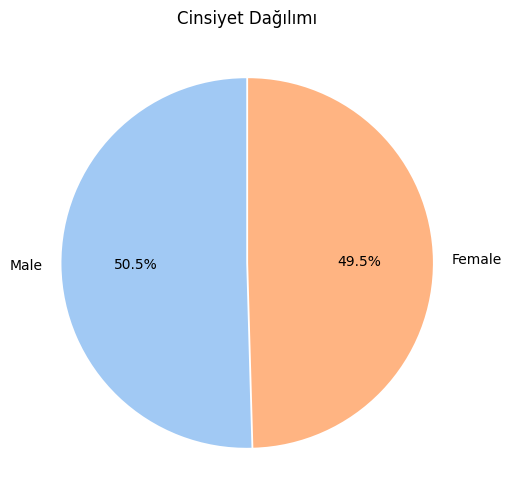

In [ ]:
sex_counts = data['sex'].value_counts()
color = sns.color_palette('pastel')
explode = [0.005] * len(sex_counts)  

plt.figure(figsize=(8,6))
plt.pie( sex_counts,startangle=90,
         explode=explode,
           labels=sex_counts.index,
             autopct='%.1f%%',
               colors=color )

plt.title('Cinsiyet Dağılımı')
plt.show()


# wedgeprops={'width': 0.4, 'edgecolor': 'w'}   ortasını boşaltmak için parametre

- katagorik değişkenlerin dağılımı

   - species(Tür): Tür dağılımına bakıldığında baskın sınıf Adelie olarak görülmektedir ardından Gentoo ve  en düşük sınıf olan Chinstrap gelmektedir gurupların dengeli olmaması istatiksel testlerde ayrıca modellerde daha fazla hata ve gürültü  olacağını göstermektedir 

   - island (Ada): Mekansal dağılıma bakıldığında örneklemin çoğunluğu Biscoe adasında bulunduğu görülmektedir. Diğer iki sınıf olan Dream ve Torgersen birbirine yakın olsada halla aralarında 60 değerlik bir fark bulunmaktadır bu da buradaki sınıf dengesizliğnin tür değişkeninden daha falzla olduğu anlaşılır. Bu dengesizlik modelin Biscoe adasına yanlı olacağını gösterir

<function matplotlib.pyplot.show(close=None, block=None)>

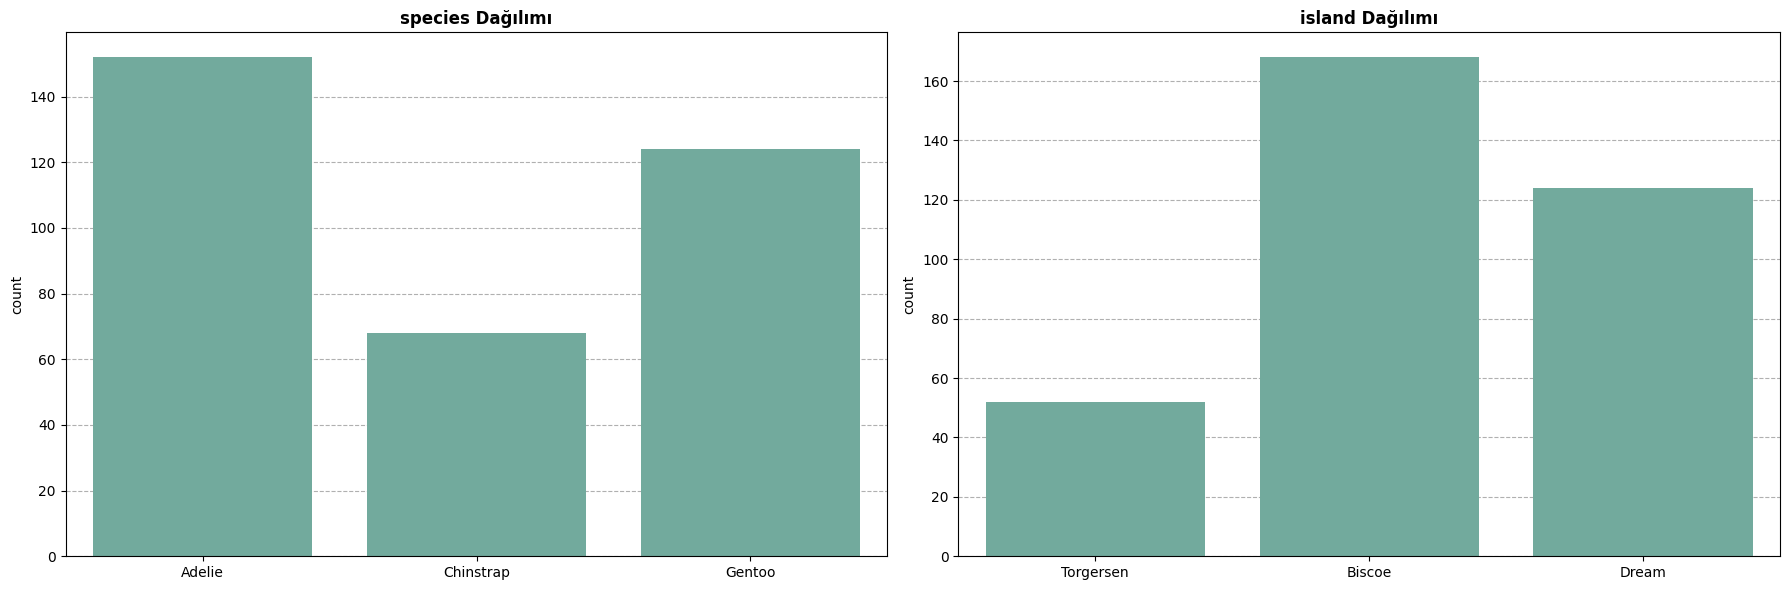

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, col in enumerate(['species', 'island']):
    sns.countplot(x=data[col], zorder=2, ax=axes[i], color='#69b3a2')
    axes[i].grid(axis='y', linestyle='--', zorder=0.05 )
    axes[i].set_title(f'{col} Dağılımı', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show

In [108]:
data.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

- Nümerik Değişkenelrin analizi  
  -  bill_length_mm (Gaga Uzunluğu): değişkende iki tepe görülmekte bu da iki gurubun farkı olarak algılanabilir cinsiyet veya türe göre penguenleri gaga uzunlukları farklıaşıyor olabilir bu da grafikte net bir şekilde gözleniyor bunun dışında gurupları ayrı ayrı ele alırsak yani iki tepeyi veride diklik söz konusu bu da verinin mod etrafında toplandığını gösteriyor

  - bill_depth_mm (Gaga Kalınlığı): gaga kalınlığında da diklik söz konusu ama gurupların farkı az olsada burada da anlaşılmaktadır belirli bir türün gaga kalınlığı 14-16 arasında olmasına rağmen tüm değişkene bakılıdığınıda  genel olarak penguenlerin gaga kalınlığının 16-20 arasında değerler aldığı görülmektedir 

  - flipper_length_mm (Yüzgeç uzunluğu): yüzgeç uzunluklarında yine guruplar arasıdaki fark öne çıkmakta bu değişkende fark diğer değişkenlere nazaran oldukça fazla iki tepe net  bir şekilde birbirinden ayrılmakta diğer değişkenlere nazaran normal dağılıma yakın olan değişkendir bu değişkende de mod değeri diğer değerlerden fazla olduğundan veri de diklik gözlenmektedir

  -  body_mass_g (Vücut kütlesi): değişkende ilk gözlenen sağa çarpık olması ve ayrıca diklik gözlenmesi bu değişkende gurupların arasındaki fark gözlenmiyor diğer değişkenlere nazaran 

- Genel çıkarım: verilerde deve hörgücü gözlenmesi iki guruplu olması iki sınıflı olan Tür değişkenine işaret olabilir ayrıca genel olarak değişkenlerin tamamında diklik ve çarpıklık görülmekte bu da aykırı değerlere bir önceki analizde gözlenen sınıf dengesizliğinin sebebi olabilir 

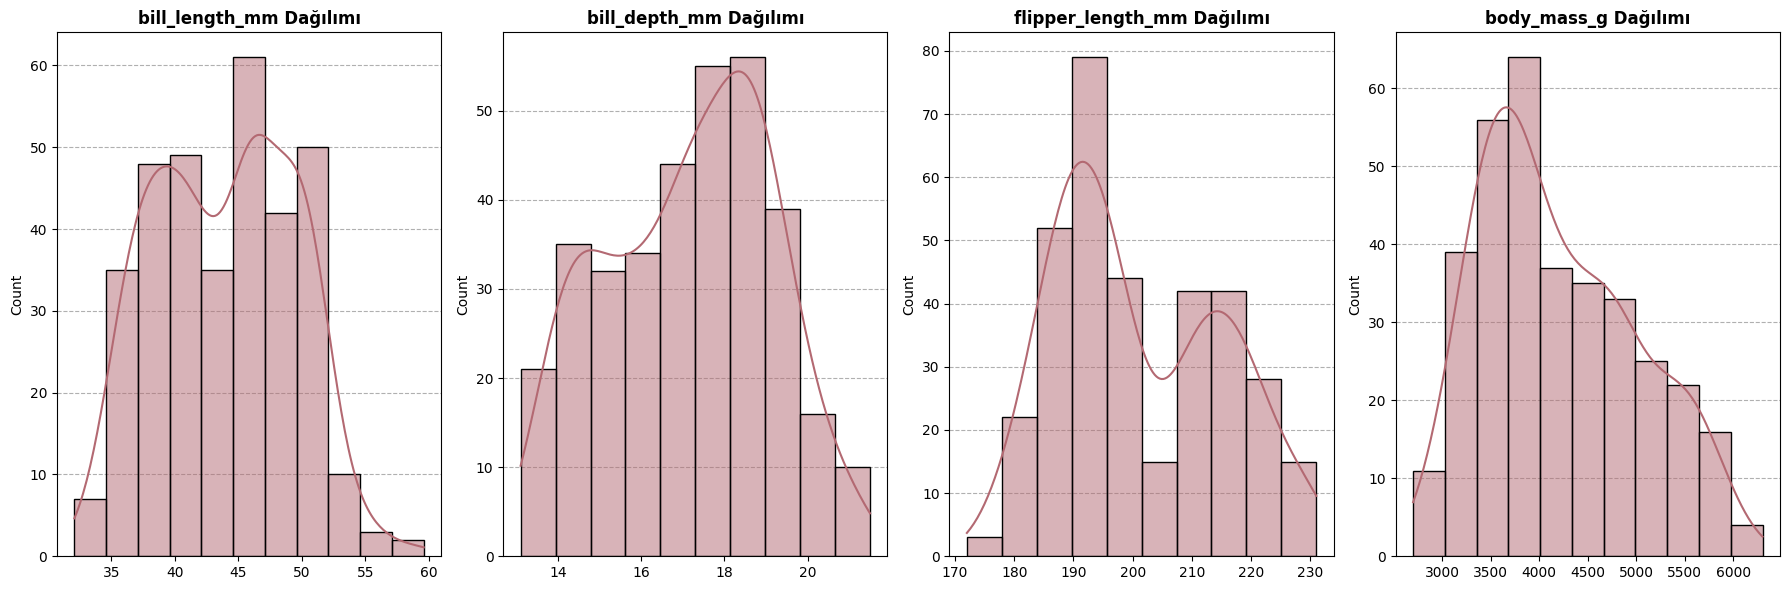

In [109]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
num_col = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for i, col in enumerate(num_col):
    sns.histplot(x=data[col], ax=axes[i], color="#b36972", zorder=2, kde=True)
    axes[i].grid(axis='y', linestyle='--', zorder=0.05)
    axes[i].set_title(f'{col} Dağılımı', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

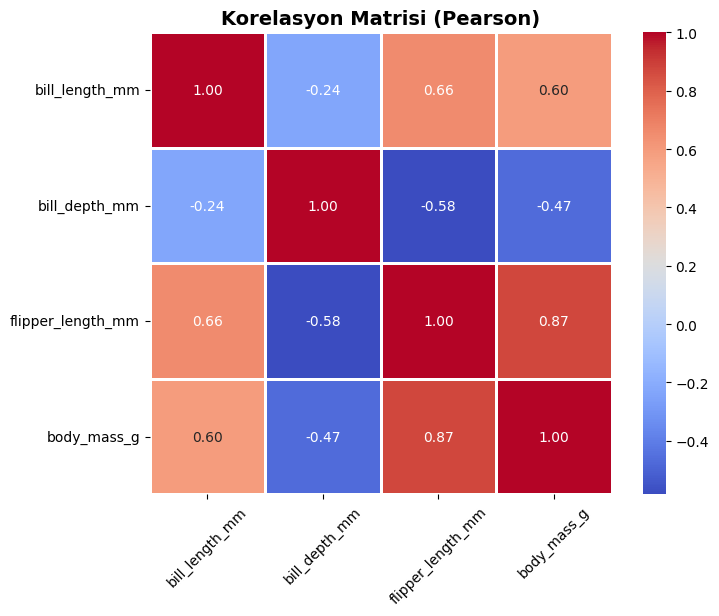

In [110]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(data=corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=1, linecolor='white', square=True)
plt.title('Korelasyon Matrisi (Pearson)', fontsize=14, fontweight='bold')
plt.xticks(rotation = 45)
plt.show()

- pairplot analizi
 - köşegen graikleri göz önünde bulundurulduğunda gentoo ve adelie değişkenlerinin bir çok konuda birbirlerinden ayrıştıkları ama chinstrap değişkenin ise adelie türünün özellikleri ile benzer özellikler göstersede gaga uzunluğu koonusunda gentoo türüne daha çok benzemektedir

 - scatter plotlar ise bir çok değişkende ayrışma söz konusu olsada chinstrap türü diğer türlerden net olarak ayrışamamış olup benzer özellikler göstermektedir 
 - görüldüğü üzere tür farklılıkları ve benzerlikleri düşünüldüğünde kurulan model için chinstrap tütü sorun teşkil etmektedir ayrışmanın net olmaması tahmin edilmesini zorlaştıracaktır nasıl

<Figure size 1000x1000 with 0 Axes>

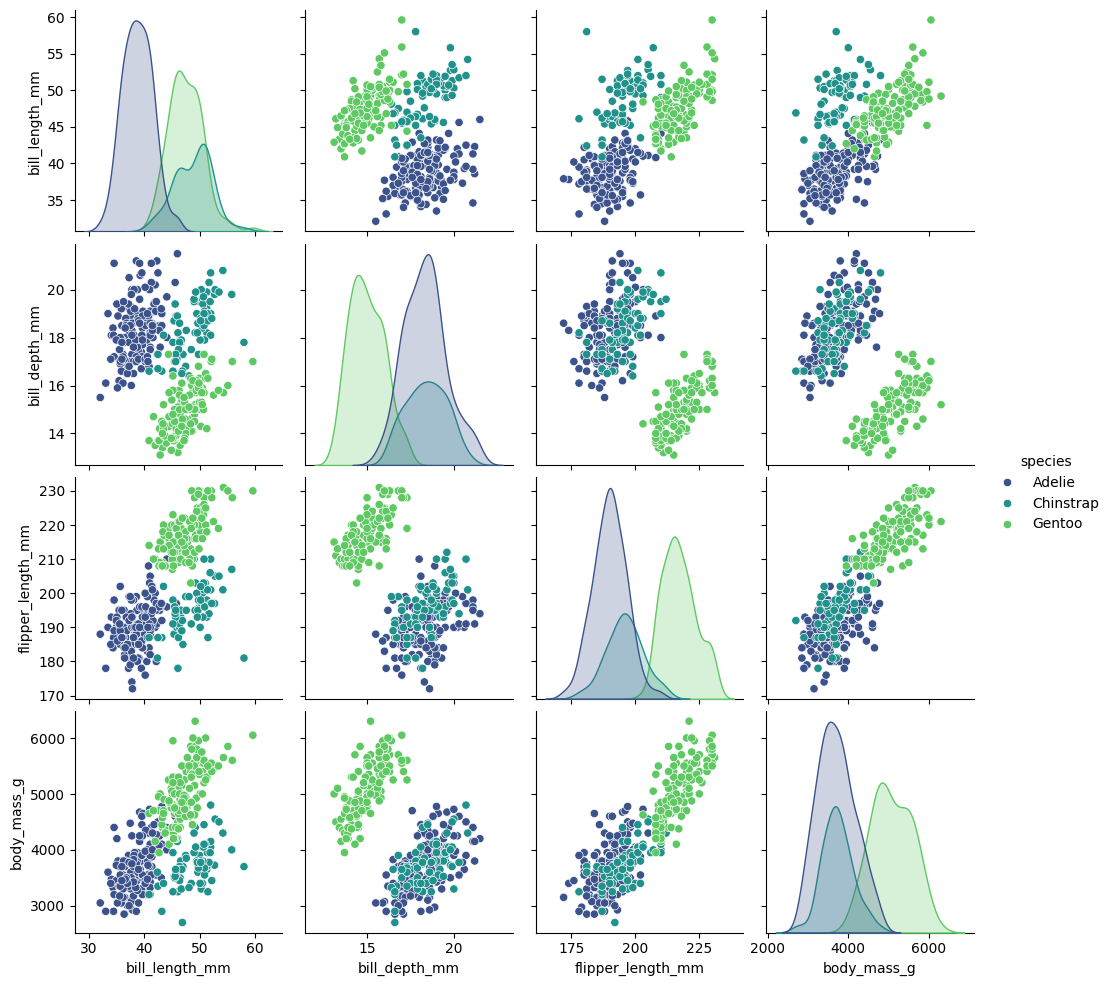

In [111]:
plt.figure(figsize=(10, 10))
sns.pairplot(data=data, hue='species', palette='viridis')
plt.show()

- flipper_length_mm & body_mass_g: Gentoo türü diğer iki türe göre hem yüzgeç uzunluğu hem de vücut kütlesi bakımından bariz bir şekilde ayrışıyor bu iki değişken Gentoo türünü tespit etmek için tek başına bile yeterli olabilir.

- bill_depth_mm: gentoo türü burada diğerlerinden daha düşük değerlere sahip adelie ve chinstrap gaga derinliğinde benzerken gentoo daha ince gagalıdır

- bill_length_mm: adelie diğerlerinden bariz şekilde daha kısa gagaya sahip chinstrap ve gentoo ise bu özellikte benzer dağılıyor

Özellikle Chinstrap türünde body_mass_g ve flipper_length değişkenlerinde, Gentoo türünde ise bill_length_mm değişkeninde aykırı değerler (noktalar) var.

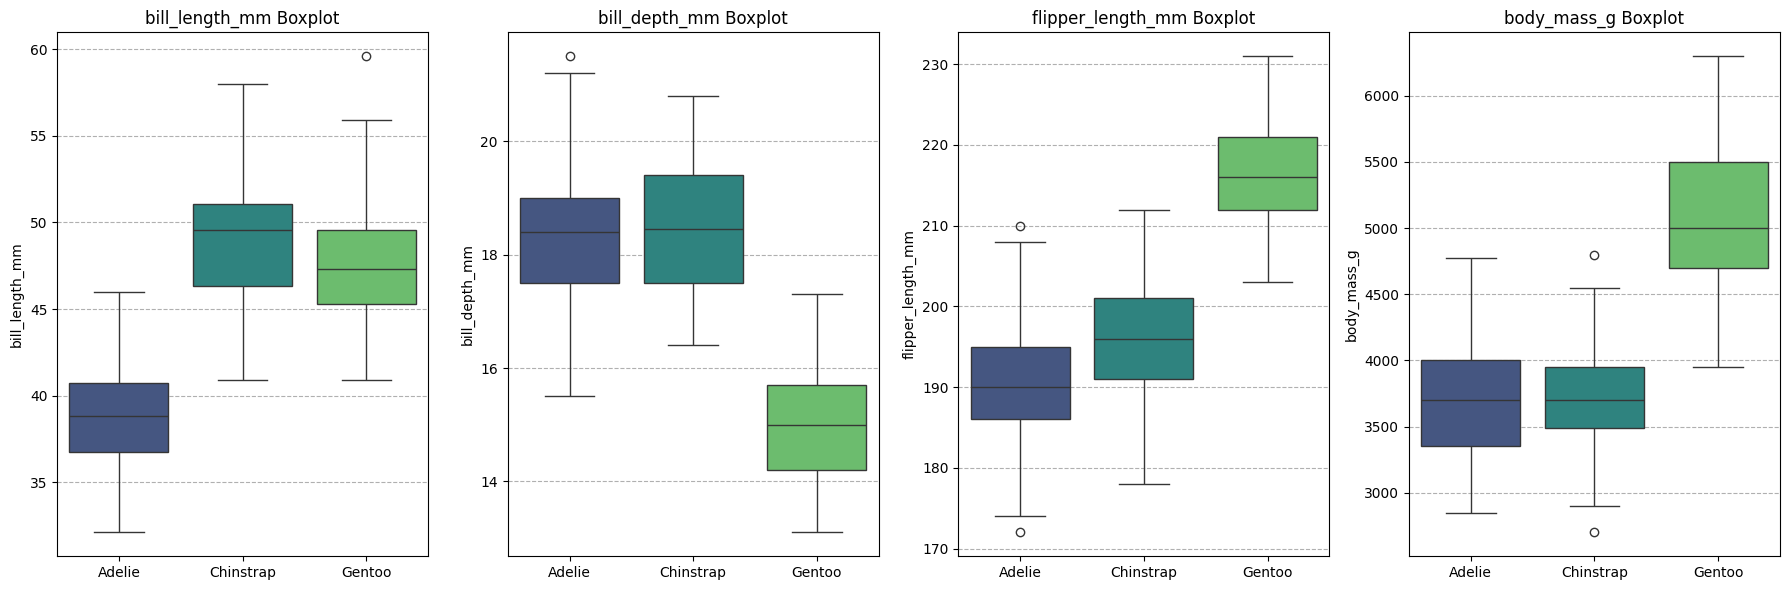

In [112]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
axes = axes.flatten()
for i, col in enumerate(num_col):
    sns.boxplot(data=data, x='species',hue='species', y= col, palette='viridis', ax=axes[i])
    axes[i].set_title(f'{col} Boxplot')
    axes[i].grid(axis='y', linestyle='--', zorder=0)
    axes[i].set_xlabel('')
plt.tight_layout()    
plt.show()

sıfır hipotez : üç türün ortalamaları eşittir görülen farklar şans eseridir
alternatif hipotez = bu üç türden en az birinin ortalaması diğerlerinden istatiksel olarak anlamlı derecede farklıdır 

anova sonuçlarına bakıldığında p < 0.05 olduğundan h0 yani sıfır hipotezinin reddediği görülmektedir F değerleri incelendiğinde en yüksek değerlerin sırasıyla flipper_length_mm değişkeni ve bill_length_mm olduğu anlaşılır bu da en fazla bilginin bu iki değişkende olduğunu gösterir türlerin farklılığını açıklayan en iyi değişkenler oldukları anlaşılmış olur.

In [113]:
print('--------------TEK YÖNLÜ ANOVA TESTİ---------------')

for col in num_col:
    group_adelie = data[data['species'] == 'Adelie'][col].dropna()
    group_chinstrap = data[data['species'] == 'Chinstrap'][col].dropna()
    group_gentoo = data[data['species' ] == 'Gentoo'][col].dropna()

    f_stat, p_value = stats.f_oneway(group_adelie, group_chinstrap, group_gentoo)

    print(f"\nDeğişken: {col}")
    print(f"F-Değeri: {f_stat:.2f}, P-Değeri: {p_value:.4f}")

    if p_value < 0.05:
        print("SONUÇ: H0 Reddedildi. Türler arasında bu özellikte ANLAMLI fark var.")
    else:
        print("SONUÇ: H0 Reddedilemedi. Fark anlamsız.")

print('--------------------------------------------------')

--------------TEK YÖNLÜ ANOVA TESTİ---------------

Değişken: bill_length_mm
F-Değeri: 410.60, P-Değeri: 0.0000
SONUÇ: H0 Reddedildi. Türler arasında bu özellikte ANLAMLI fark var.

Değişken: bill_depth_mm
F-Değeri: 359.79, P-Değeri: 0.0000
SONUÇ: H0 Reddedildi. Türler arasında bu özellikte ANLAMLI fark var.

Değişken: flipper_length_mm
F-Değeri: 594.80, P-Değeri: 0.0000
SONUÇ: H0 Reddedildi. Türler arasında bu özellikte ANLAMLI fark var.

Değişken: body_mass_g
F-Değeri: 343.63, P-Değeri: 0.0000
SONUÇ: H0 Reddedildi. Türler arasında bu özellikte ANLAMLI fark var.
--------------------------------------------------


In [114]:
data.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

### Nümerik verilerdeki eksik değerlerin doldurulması 

In [115]:
for col in num_col:
    data[col] = data[col].fillna(data.groupby('species')[col].transform('mean'))

data['sex'] = data.groupby('species')['sex'].transform(lambda x: x.fillna(x.mode()[0]))
 
data['sex'] = data['sex'].map({'Male': 1, 'Female': 0})
 
le = LabelEncoder()
data['species'] = le.fit_transform(data['species'])
 
data = pd.get_dummies(data, columns=['island'], drop_first=True)
 
scaler = StandardScaler()
data[num_col] = scaler.fit_transform(data[num_col])

In [116]:
data.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Dream,island_Torgersen
0,0,-0.884552,0.787370,-1.419545,-0.565840,1,False,True
1,0,-0.811106,0.127702,-1.063424,-0.503363,0,False,True
2,0,-0.664214,0.432164,-0.422406,-1.190609,0,False,True
3,0,-0.941217,0.607919,-0.781829,-0.627489,0,False,True
4,0,-1.325227,1.091831,-0.564854,-0.940701,0,False,True


Accuracy: %98.55

Rapor:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        32
           1       1.00      0.94      0.97        16
           2       1.00      1.00      1.00        21

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



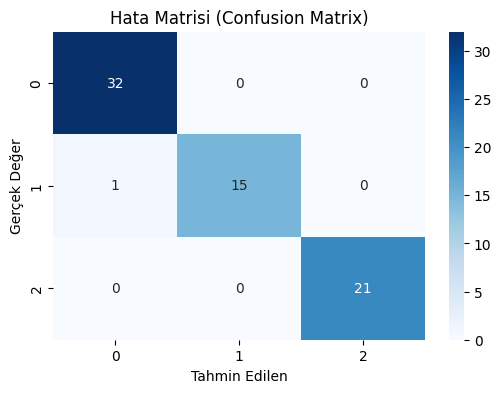

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
 
X = data.drop('species', axis=1)   
y = data['species']                

 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
 
model = LogisticRegression()
model.fit(X_train, y_train)
 
y_pred = model.predict(X_test)
basari_orani = accuracy_score(y_test, y_pred)

print(f"Accuracy: %{basari_orani * 100:.2f}")
print("\nRapor:\n")
print(classification_report(y_test, y_pred))
 
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Hata Matrisi (Confusion Matrix)')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()

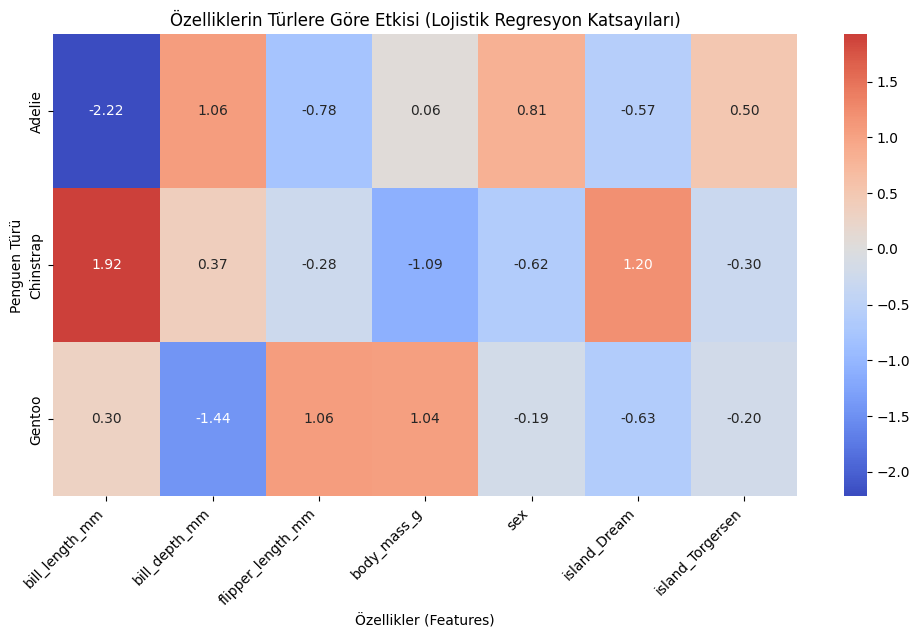

In [118]:
coef_df = pd.DataFrame(model.coef_, columns=X.columns)
coef_df.index = ['Adelie', 'Chinstrap', 'Gentoo']

plt.figure(figsize=(12, 6))
sns.heatmap(coef_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Özelliklerin Türlere Göre Etkisi (Lojistik Regresyon Katsayıları)')
plt.ylabel('Penguen Türü')
plt.xlabel('Özellikler (Features)')
plt.xticks(rotation=45, ha='right')
plt.show()